# **Sales Analysis**

In [1]:
import pandas as pd
import numpy
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [3]:
sales_df = pd.read_csv(
    'dataset/processed/ecommerce_processed.csv',
    parse_dates=['order_date']
)

In [4]:
sales_df.sample(10)

,order_date,order_year,order_month,order_day_of_week,part_day,is_weekend,customer_name,gender,age,age_group,customer_segment,country,order_status,category,sub_category,unit_price_usd,price_tier,quantity,quantity_segment,gross_revenue_usd,discount_amount_usd,discount_percent,discount_tier,is_discounted,revenue_usd,order_value_segment,profit_usd,profit_margin_percent,payment_method,shipping_method,shipping_cost_usd,shipping_cost_percent,delivery_days,delivery_speed,shipping_country,shipment_type,rating,customer_loyalty_score,loyalty_tier,coupon_used,session_duration_min,engagement_level,pages_visited,abandoned_cart_before,fraud_risk_score,fraud_risk_level,device_type,campaign_source,traffic_source
345451,2024-07-13 13:56:11.998591,2024,7,Sat,Afternoon,Yes,Amy Collins,Female,73,65+,Regular,Italy,Pending,Sports,Sports Wear,195.32,Premium,3,Small Basket,585.96,29.30,5,Low Discount,Yes,556.66,High,273.85,49.20,Credit Card,Standard,11.20,2.01,6,Standard,Italy,Domestic,2,17.30,Low,No,29.30,Medium,8,Yes,75.90,High,Mobile,Instagram,Search
812758,2024-04-18 10:06:13.873370,2024,4,Thu,Morning,No,Melissa Wiggins,Female,68,65+,VIP,France,Completed,Sports,Sports Wear,134.25,Premium,5,Bulk,671.25,67.12,10,Low Discount,Yes,604.13,Very High,286.08,47.35,Apple Pay,Next Day,24.66,4.08,5,Standard,France,Domestic,2,32.40,Medium,Yes,19.40,Medium,19,Yes,92.80,High,Mobile,Affiliate,Referral
574420,2024-06-15 16:32:53.919496,2024,6,Sat,Afternoon,Yes,Jonathan Downs,Male,48,45-54,Regular,United States,Completed,Sports,Sports Wear,81.57,Mid-Range,5,Bulk,407.85,61.18,15,Medium Discount,Yes,346.67,High,94.32,27.21,Apple Pay,Express,0.79,0.23,13,Slow,United States,Domestic,2,35.30,Medium,No,10.80,Low,19,No,67.80,Medium,Mobile,Email,Email
254817,2024-08-20 07:56:51.766941,2024,8,Tue,Morning,No,Willie Jenkins,Male,22,18-24,Regular,Netherlands,Completed,Electronics,Audio,144.79,Premium,3,Small Basket,434.37,21.72,5,Low Discount,Yes,412.65,High,125.04,30.30,Apple Pay,Next Day,3.26,0.79,2,Fast,Netherlands,Domestic,3,91.70,High,Yes,9.20,Low,12,No,81.30,High,Mobile,Organic,Social
467151,2024-12-04 00:18:20.129639,2024,12,Wed,Night,No,Eric Watson,Male,44,35-44,Regular,United Kingdom,Completed,Clothing,Shoes,17.09,Budget,2,Small Basket,34.18,1.71,5,Low Discount,Yes,32.47,Low,17.79,54.79,PayPal,Standard,11.76,36.22,3,Fast,United Kingdom,Domestic,3,11.80,Low,No,5.20,Low,7,Yes,68.30,Medium,Desktop,Facebook,Direct
310105,2025-10-03 20:39:08.355976,2025,10,Fri,Evening,No,Emma Cooper,Female,40,35-44,Regular,Australia,Cancelled,Sports,Gym Equipment,129.03,Premium,5,Bulk,645.15,64.52,10,Low Discount,Yes,580.63,High,210.73,36.29,PayPal,Economy,22.77,3.92,2,Fast,Australia,Domestic,3,7.80,Low,Yes,26.60,Medium,15,Yes,61.30,Medium,Tablet,Email,Referral
521849,2025-10-26 17:02:39.275124,2025,10,Sun,Afternoon,Yes,Jessica Curry,Female,46,45-54,Premium,Canada,Completed,Sports,Accessories,107.88,Premium,1,Single,107.88,21.58,20,Medium Discount,Yes,86.30,Low,26.37,30.56,Debit Card,Express,8.48,9.83,7,Standard,Canada,Domestic,1,72.60,High,No,31.30,Medium,3,Yes,36.00,Medium,Desktop,Facebook,Email
784742,2024-07-07 16:38:30.788824,2024,7,Sun,Afternoon,Yes,Christopher Washington,Male,66,65+,Regular,Germany,Completed,Health,Supplements,108.29,Premium,1,Single,108.29,27.07,25,High Discount,Yes,81.22,Low,32.40,39.89,Apple Pay,Express,24.20,29.80,4,Standard,Germany,Domestic,1,17.30,Low,No,26.20,Medium,18,No,23.50,Low,Mobile,Email,Search
808877,2025-06-08 07:22:18.513476,2025,6,Sun,Morning,Yes,Lisa Thomas,Female,55,55-64,Premium,Italy,Completed,Clothing,Shoes,58.02,Mid-Range,4,Bulk,232.08,34.81,15,Medium Discount,Yes,197.27,Medium,43.23,21.91,Credit Card,Standard,0.73,0.37,5,Standard,Italy,Domestic,5,40.80,Medium,Yes,6.10,Low,14,Yes,6.30,Low,Desktop,Email,Referral
322619,2025-07-08 16:13:53.707456,2025,7,Tue,Afternoon,No,James Morgan,Male,26,25-34,Premium,Canada,Completed,Clothing,Mens Wear,22.43,Budget,2,Small Basket,44.86,4.49,10,Low Discount,Yes,40.37,Low,14.49,35.89,Bank Transfer,Economy,19

## 1.1 Revenue by Time

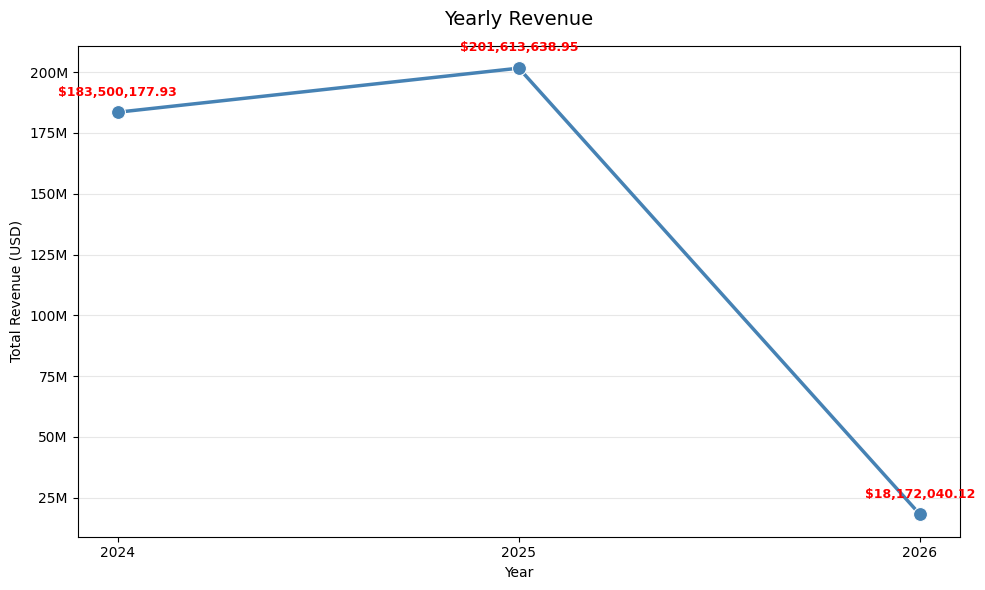

In [5]:
# 1.1.1 Yearly Revenue

yearly_revenue = (
    sales_df.groupby('order_year')['revenue_usd']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=yearly_revenue,
    x='order_year',
    y='revenue_usd',
    marker='o',
    markersize=10,
    linewidth=2.5,
    color='steelblue',
)

# Add value labels on each marker
for x, y in zip(yearly_revenue['order_year'], yearly_revenue['revenue_usd']):
    ax.annotate(
        f'${y:,}',              
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='red'
    )

plt.title('Yearly Revenue', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Total Revenue (USD)')
plt.xticks(yearly_revenue['order_year'])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

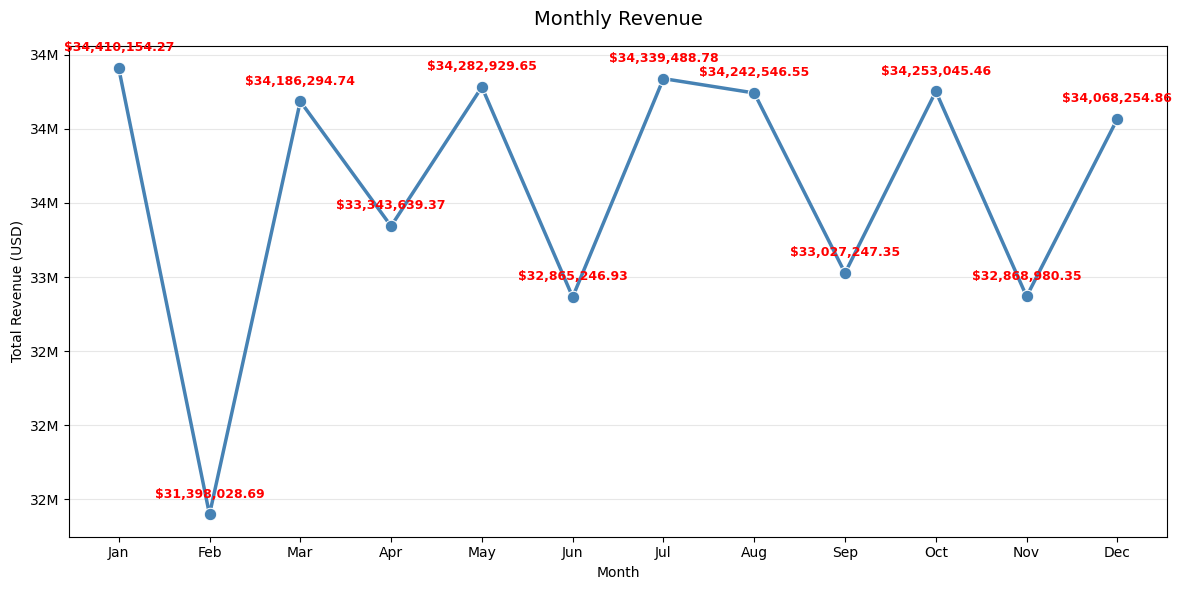

In [6]:
# 1.1.2 Monthly Revenue

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_map = {i+1: m for i, m in enumerate(month_order)}

sales_df['order_month'] = sales_df['order_month'].map(month_map)

monthly_revenue = (
    sales_df.groupby('order_month')['revenue_usd']
    .sum()
    .reindex(month_order)
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=monthly_revenue,
    x='order_month',
    y='revenue_usd',
    marker='o',
    markersize=9,
    linewidth=2.5,
    color='steelblue'
)

for x, y in zip(monthly_revenue['order_month'], monthly_revenue['revenue_usd']):
    ax.annotate(
        f'${y:,}',
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='red'
    )

plt.title('Monthly Revenue', fontsize=14, pad=15)
plt.xlabel('Month')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

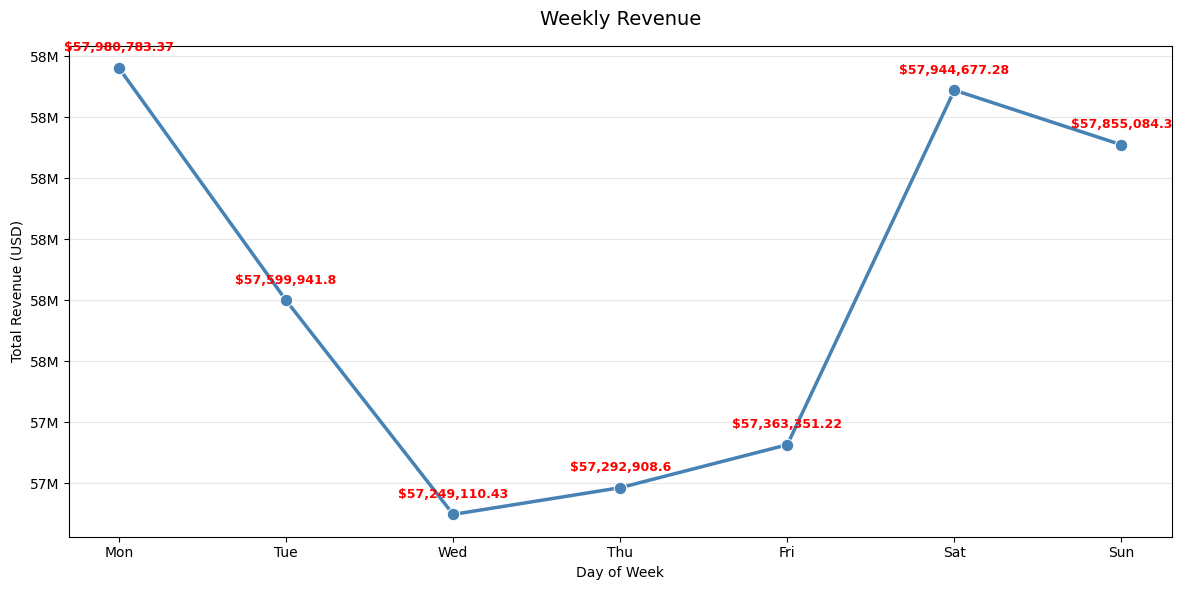

In [7]:
# 1.1.3 Day of Week Revenue

day_of_week_revenue = (
    sales_df.groupby('order_day_of_week')['revenue_usd']
    .sum()
    .reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=day_of_week_revenue,
    x='order_day_of_week',
    y='revenue_usd',
    marker='o',
    markersize=9,
    linewidth=2.5,
    color='steelblue',
)

for x, y in zip(day_of_week_revenue['order_day_of_week'], day_of_week_revenue['revenue_usd']):
    ax.annotate(
        f'${y:,}',
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='red'
    )

plt.title('Weekly Revenue', fontsize=14, pad=15)
plt.xlabel('Day of Week')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

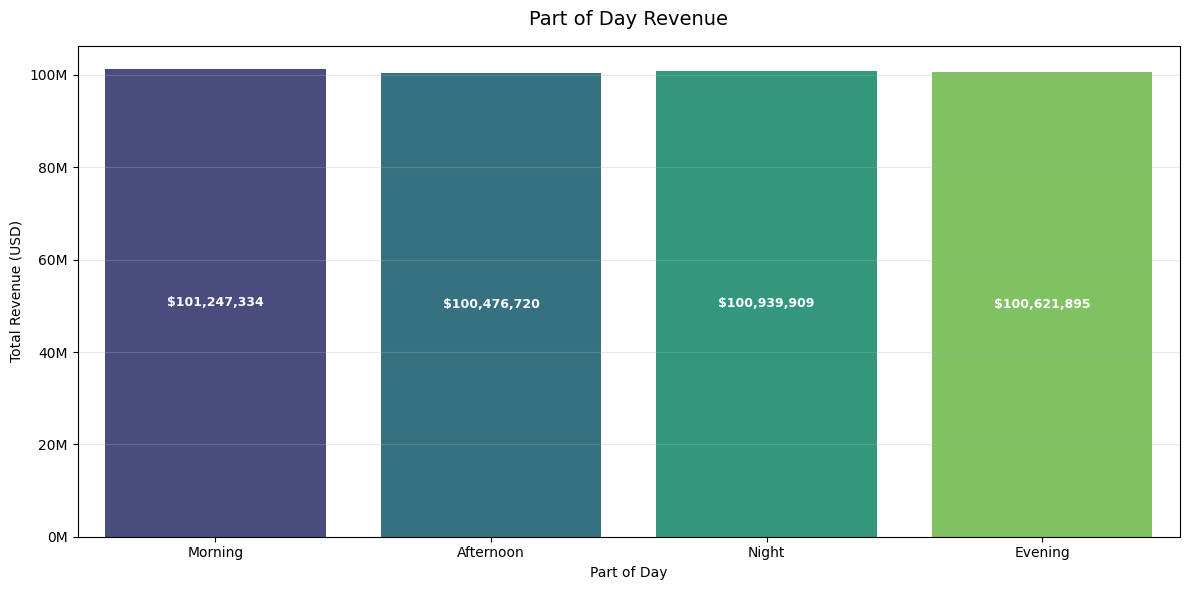

In [8]:
# 1.1.4 Part of Day Revenue

part_day_revenue = (
    sales_df.groupby('part_day')['revenue_usd']
    .sum()
    .reindex(['Morning', 'Afternoon', 'Night', 'Evening'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=part_day_revenue,
    x='part_day',
    y='revenue_usd',
    palette='viridis',
    hue='part_day',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.0f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Part of Day Revenue', fontsize=14, pad=15)
plt.xlabel('Part of Day')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

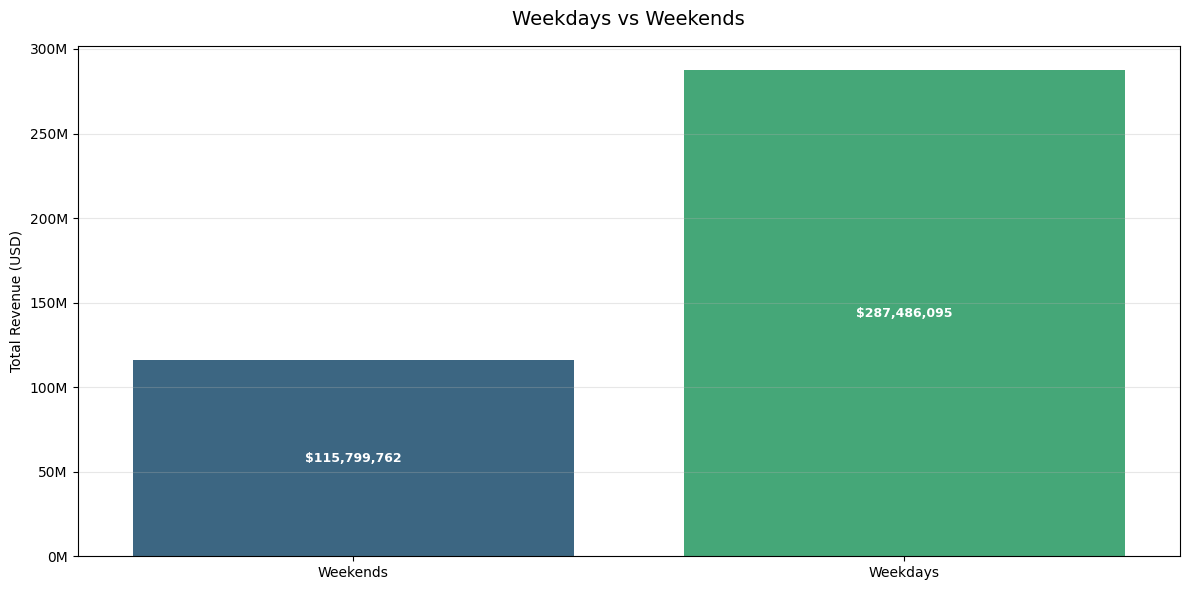

In [9]:
# 1.1.5 Weekend vs Weekedays

is_weekend_revenue = (
    sales_df.groupby('is_weekend')['revenue_usd']
    .sum()
    .reindex(['Yes', 'No'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=is_weekend_revenue,
    x='is_weekend',
    y='revenue_usd',
    palette='viridis',
    hue='is_weekend',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.0f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Weekdays vs Weekends', fontsize=14, pad=15)
plt.xlabel('')
plt.xticks([0, 1], ['Weekends', 'Weekdays'])
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.2 Revenue by Category and Sub-Category

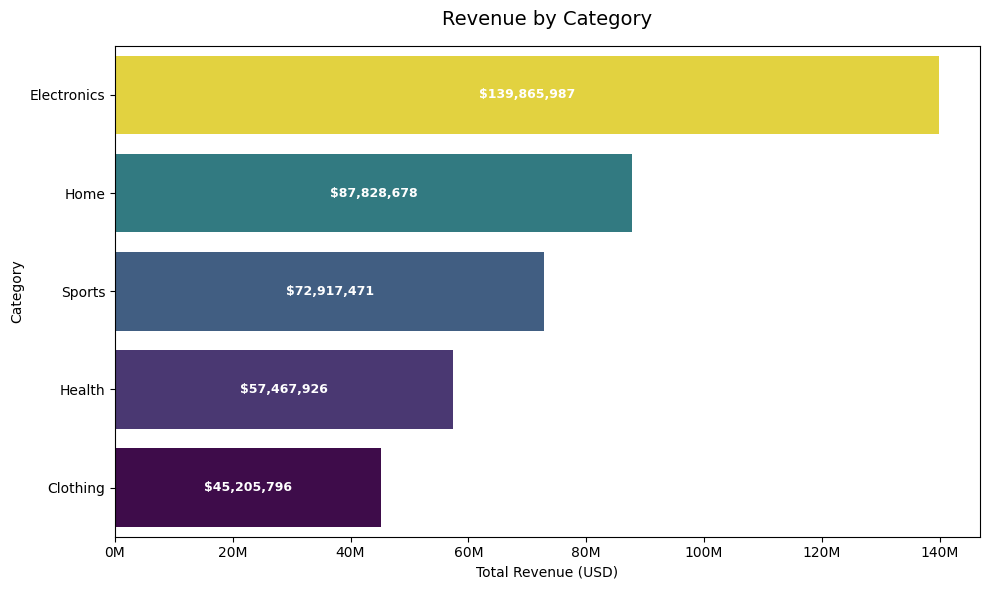

In [10]:
# 1.2.1 Revenue per Category

category_revenue = (
    sales_df.groupby('category')['revenue_usd']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=category_revenue,
    x='revenue_usd',
    y='category',
    palette='viridis',
    orient='h',
    hue='revenue_usd',
    legend=False
)


for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.0f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Revenue by Category', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Category')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.tight_layout()
plt.show()

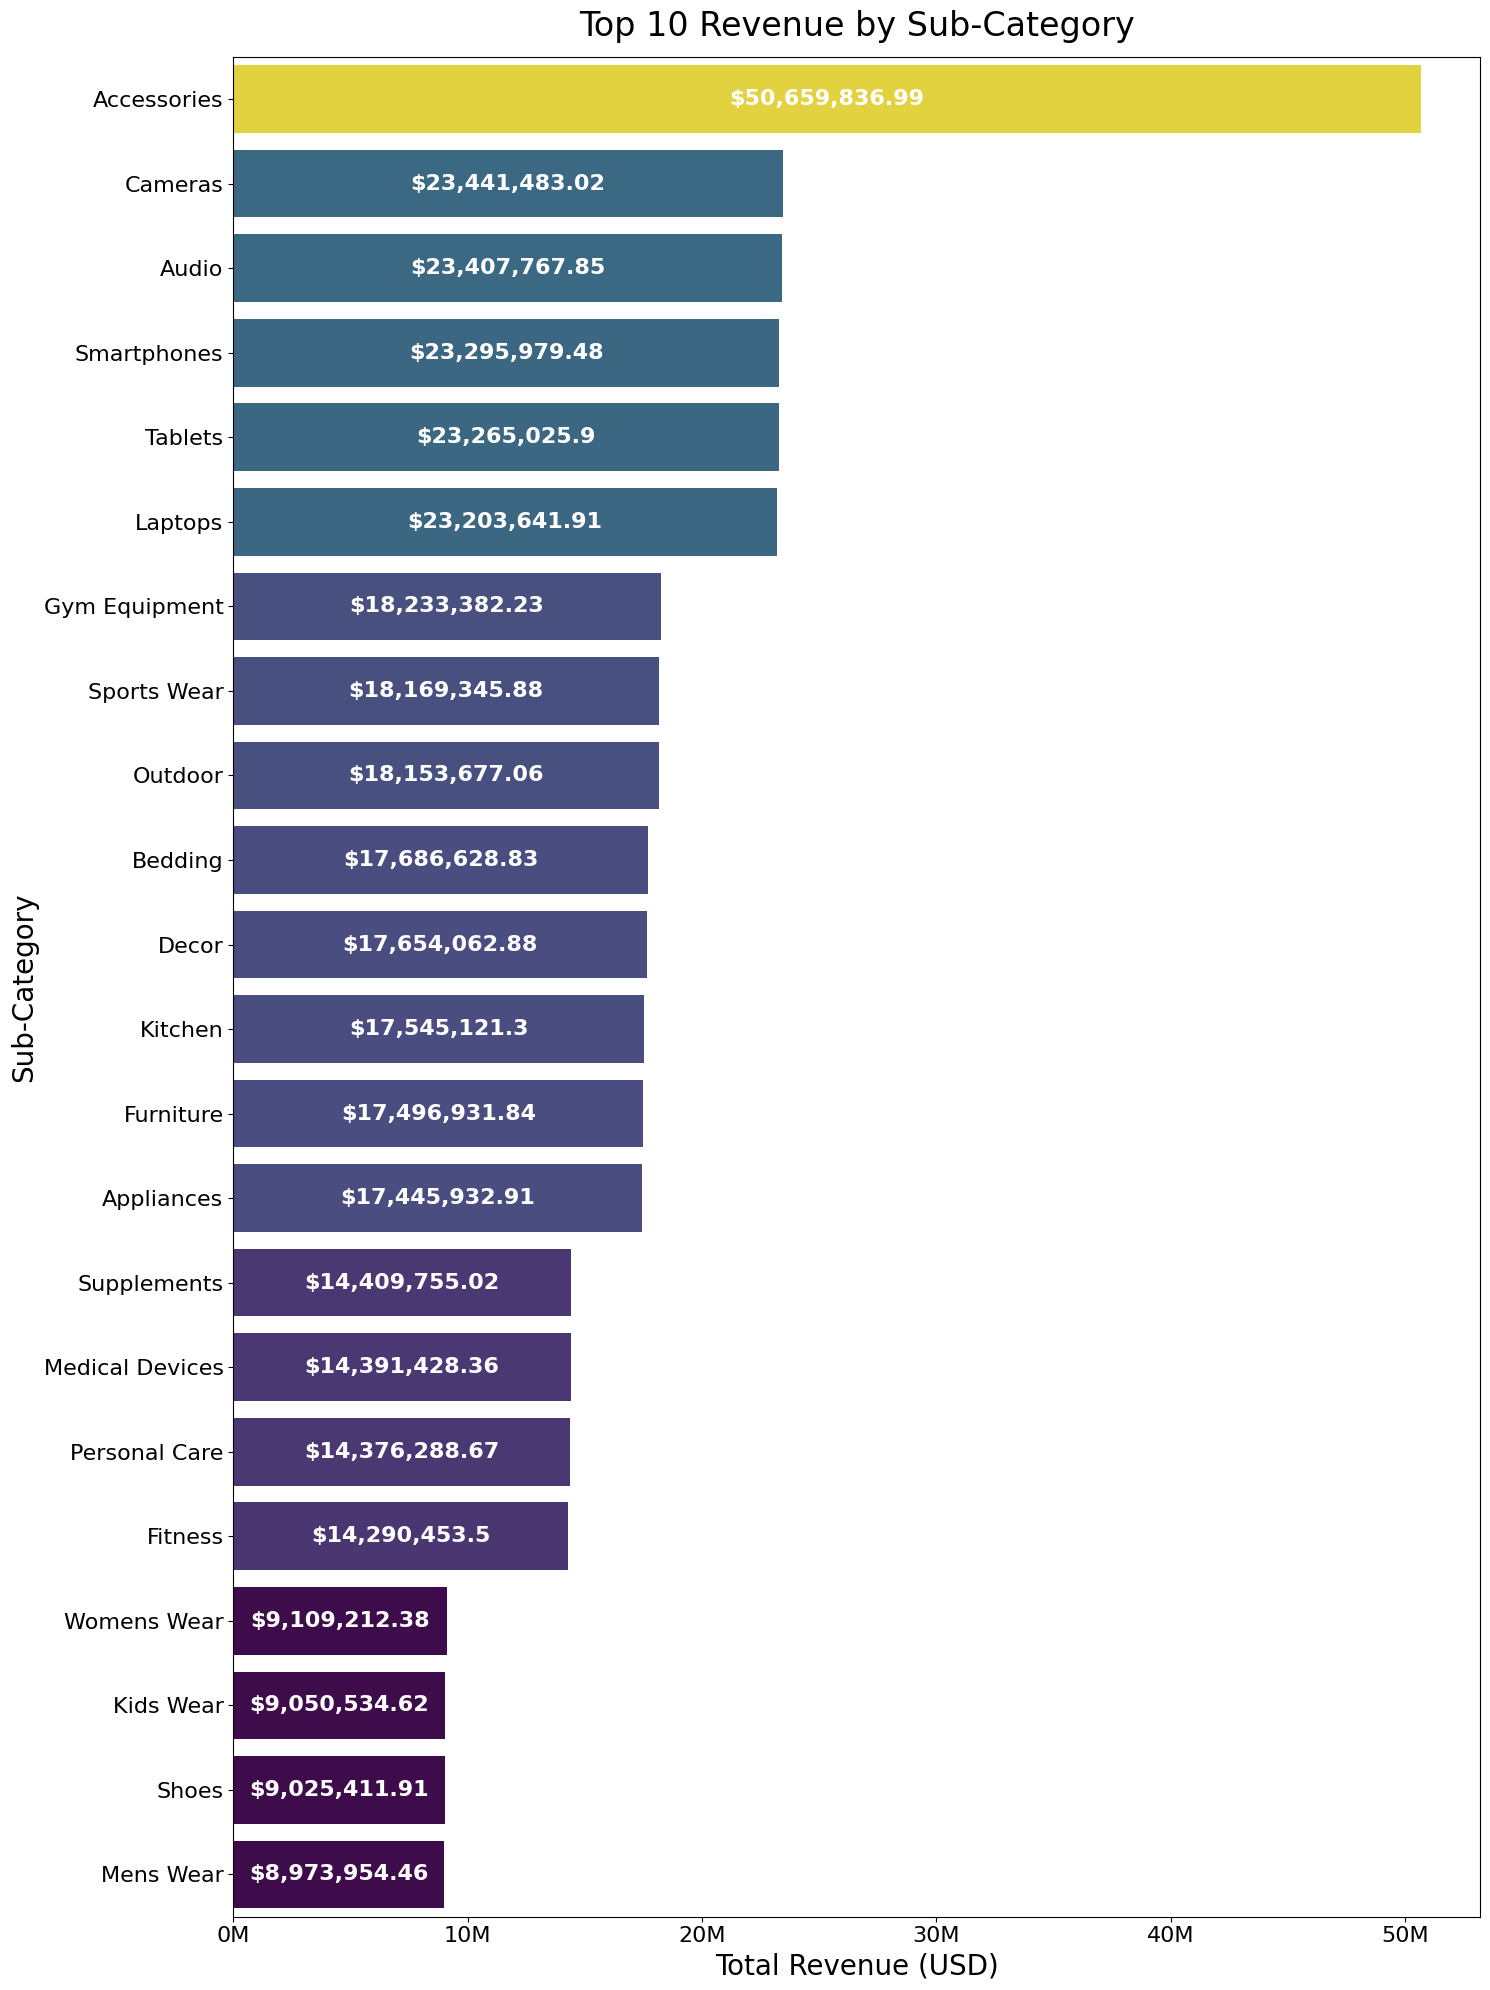

In [11]:
# 1.2.1 Top 10 Revenue Sub Category

subcategory_revenue = (
    sales_df.groupby('sub_category')['revenue_usd']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(15, 20))

ax = sns.barplot(
    data=subcategory_revenue,
    x='revenue_usd',
    y='sub_category',
    palette='viridis',
    orient='h',
    hue='revenue_usd',
    legend=False
)


for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=16,
        fontweight='bold'
    )

plt.title('Top 10 Revenue by Sub-Category', fontsize=24, pad=15)
plt.xlabel('Total Revenue (USD)', fontsize=20)
plt.ylabel('Sub-Category', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.tight_layout()
plt.show()

## 1.3 Revenue by Country

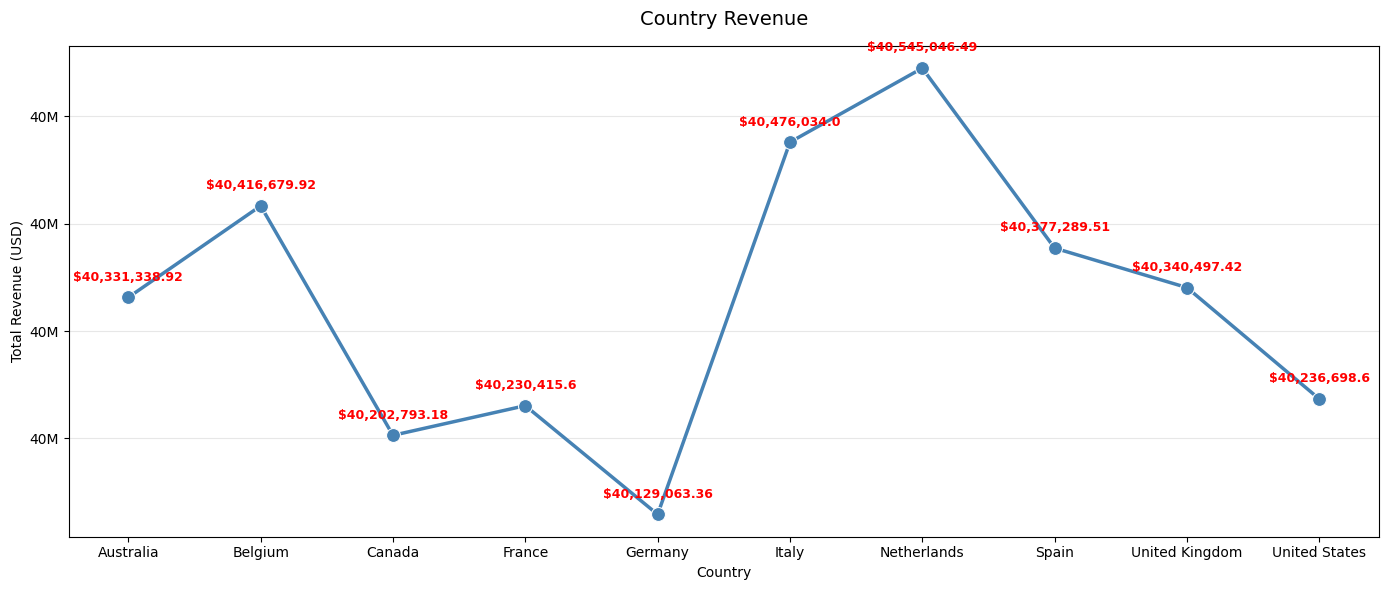

In [12]:
# 1.3.1 Country Revenue

country_revenue = (
    sales_df.groupby('country')['revenue_usd']
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 6))

ax = sns.lineplot(
    data=country_revenue,
    x='country',
    y='revenue_usd',
    marker='o',
    markersize=10,
    linewidth=2.5,
    color='steelblue',
)

# Add value labels on each marker
for x, y in zip(country_revenue['country'], country_revenue['revenue_usd']):
    ax.annotate(
        f'${y:,}',              
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='red'
    )

plt.title('Country Revenue', fontsize=14, pad=15)
plt.xlabel('Country')
plt.ylabel('Total Revenue (USD)')
plt.xticks(country_revenue['country'])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

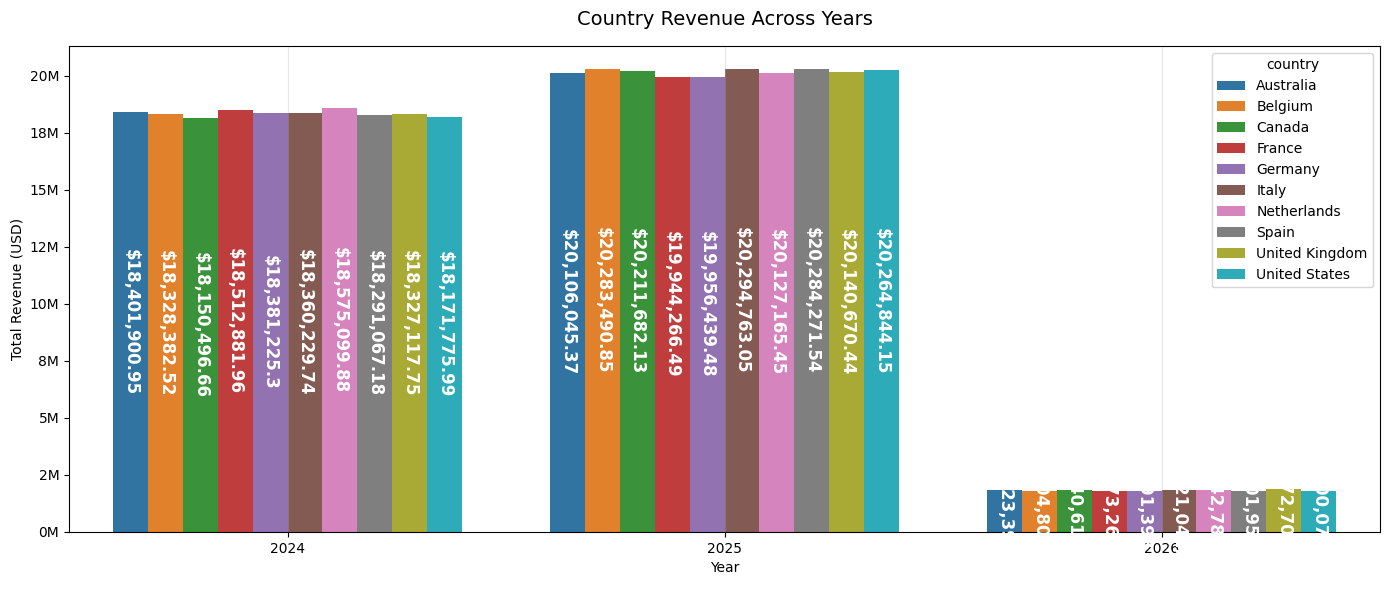

In [ ]:
# 1.3.1 Country Revenue Across Years

country_yearly_revenue = sales_df.groupby(
    ['order_year', 'country']
)['revenue_usd'].sum().reset_index()
country_yearly_revenue
plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=country_yearly_revenue,
    x='order_year',
    y='revenue_usd',
    palette='tab10',
    hue='country',
)


# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=12,
        fontweight='bold',
        rotation=-90
    )

plt.title('Country Revenue Across Years', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.4 Revenue by Order Value Segment

## 1.5 Customers

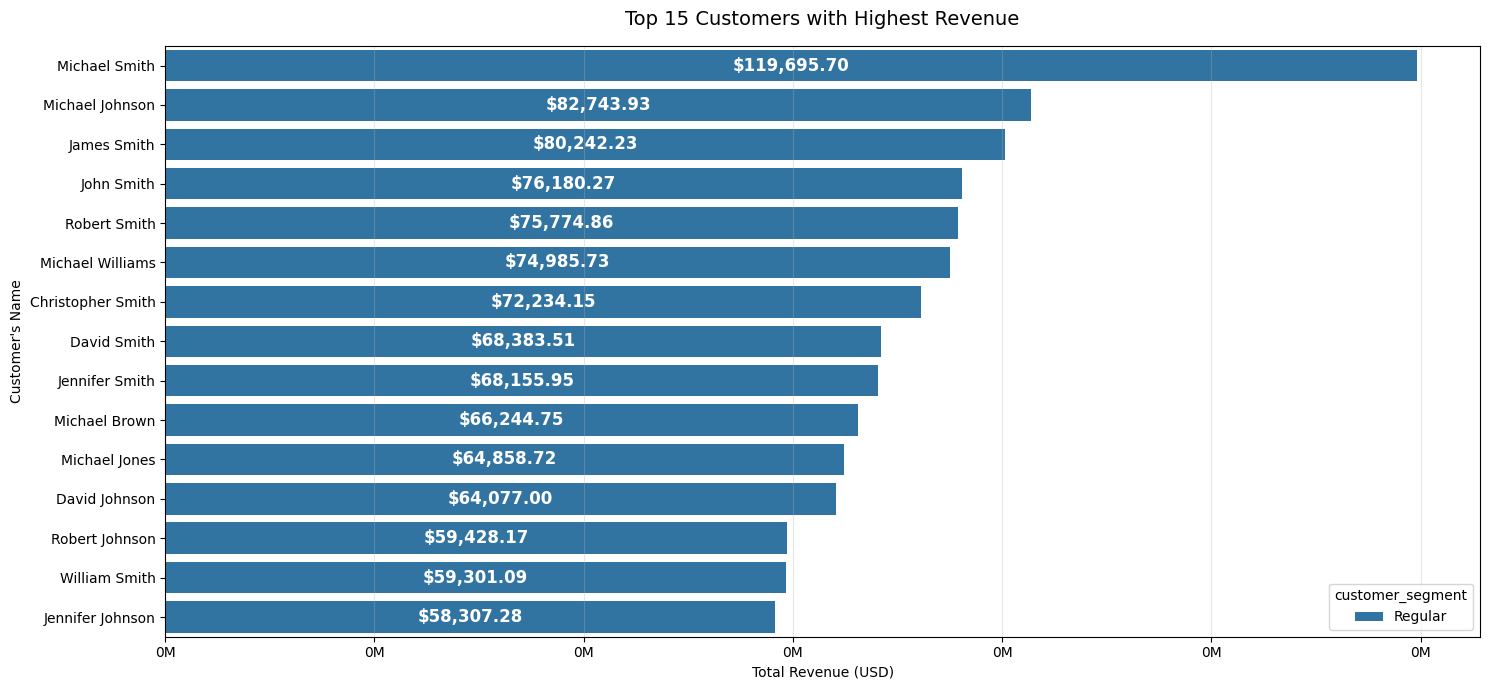

In [24]:
# Top 15 Customers with Highest Revenue and their Customer Segment

customers_highest_revenue = sales_df.groupby(['customer_name','customer_segment'])['revenue_usd'].sum().reset_index().sort_values('revenue_usd', ascending=False).head(15)

plt.figure(figsize=(15, 7))

ax = sns.barplot(
    data=customers_highest_revenue,
    x='revenue_usd',
    y='customer_name',
    hue='customer_segment',
    orient='h',
    palette='tab10'
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=12,
        fontweight='bold'
    )
    
plt.title('Top 15 Customers with Highest Revenue', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel("Customer's Name")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

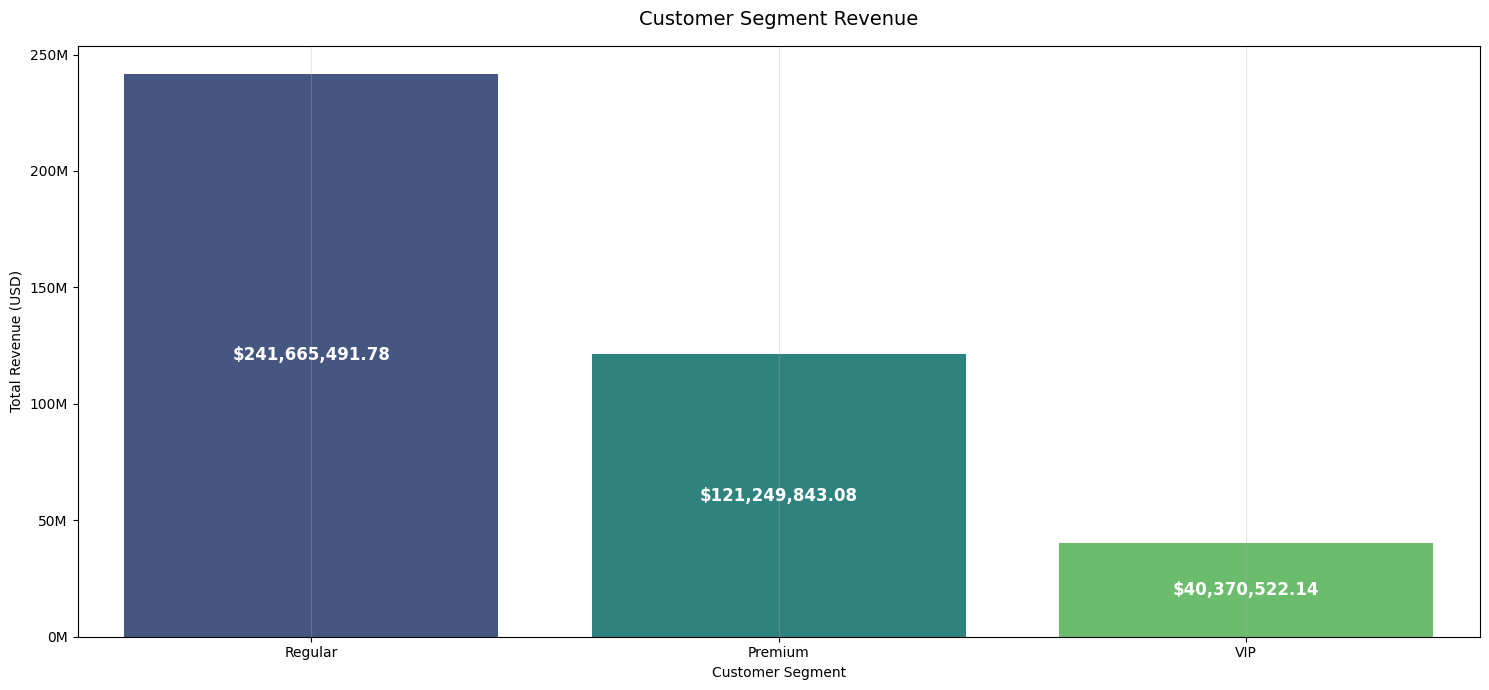

In [27]:
# Customer Segment Revenue

customer_segment_revenue = sales_df.groupby('customer_segment')['revenue_usd'].sum().reset_index().sort_values('revenue_usd', ascending=False).head(15)

plt.figure(figsize=(15, 7))

ax = sns.barplot(
    data=customer_segment_revenue,
    x='customer_segment',
    y='revenue_usd',
    hue='customer_segment',
    legend=False,
    palette='viridis'
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=12,
        fontweight='bold'
    )
    
plt.title('Customer Segment Revenue', fontsize=14, pad=15)
plt.xlabel('Customer Segment')
plt.ylabel("Total Revenue (USD)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.6 Gross Revenue (Without discount) vs Revenue (With discount applied)